<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

LOAD THE DATASET

In [ ]:
df=pd.read_csv('weather_data_extended.csv')
print(df.shape)
df.info()
df.head()

(800, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          800 non-null    object 
 1   Temperature (°C)  800 non-null    float64
 2   Feels Like (°C)   800 non-null    float64
 3   Humidity (%)      798 non-null    float64
 4   Wind Speed (kph)  798 non-null    float64
 5   Cloud Cover (%)   800 non-null    int64  
 6   Pressure (mb)     798 non-null    float64
 7   UV Index          800 non-null    int64  
 8   Visibility (km)   800 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 56.4+ KB


,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16


CHECK FOR MISSING VALUES

In [ ]:
df.isnull() .sum()

,0
Location,0
Temperature (°C),0
Feels Like (°C),0
Humidity (%),2
Wind Speed (kph),2
Cloud Cover (%),0
Pressure (mb),2
UV Index,0
Visibility (km),0


REMOVE NULL VALUES

In [ ]:
df=df.dropna()
df.isnull() .sum()
#df.dropna()

,0
Location,0
Temperature (°C),0
Feels Like (°C),0
Humidity (%),0
Wind Speed (kph),0
Cloud Cover (%),0
Pressure (mb),0
UV Index,0
Visibility (km),0


CHECK THE DATASET INFO

In [ ]:
df.describe()

,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,16.580730,16.373804,73.513854,16.123300,43.513854,1013.041562,1.746851,10.732997
std,5.574821,7.382814,16.478897,10.338986,34.845115,7.608453,1.092285,1.966105
min,8.300000,4.500000,40.000000,3.600000,0.000000,900.000000,1.000000,10.000000
25%,15.000000,13.800000,67.000000,6.100000,0.000000,1012.000000,1.000000,10.000000
50%,16.000000,16.000000,76.000000,9.000000,50.000000,1013.000000,1.000000,10.000000
75%,24.000000,25.500000,88.000000,24.100000,75.000000,1019.250000,2.000000,10.000000
max,25.000000,27.800000,100.000000,29.900000,75.000000,1024.000000,4.000000,16.000000


USE THE 'MAP' FUNCTION TO CHANGE STRING TO INTEGER

In [ ]:
df['Location_index'] = df['Location'].astype('category').cat.codes
df.head()

,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km),Location_index
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3


In [ ]:
unique_locations = df['Location'].drop_duplicates().reset_index(drop=True)
unique_location_indices = df['Location_index'].drop_duplicates().reset_index(drop=True)


In [ ]:
unique_df = pd.DataFrame({
    'Unique_Locations': unique_locations,
    'Unique_Location_Indices': unique_location_indices
})
unique_df
df.head()

,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km),Location_index
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3


#DECLARE  MY FEATURE (X,Y)

In [ ]:
X=df[['Temperature (°C)','Feels Like (°C)','Humidity (%)','Wind Speed (kph)','Cloud Cover (%)','Pressure (mb)','UV Index','Visibility (km)','Location_index']]

FEATURE SCALING (X) SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # Instantiate the scaler
numerical_features = ['Temperature (°C)','Feels Like (°C)','Humidity (%)','Wind Speed (kph)','Cloud Cover (%)','Pressure (mb)','UV Index','Visibility (km)','Location_index']
X_scaled = scaler.fit_transform(X[numerical_features])

In [ ]:
y = df['Location_index']
#display(y.head())

In [ ]:
display(X_scaled[:5])

array([[-1.48631671, -1.60931691, -2.03502572,  1.33334007,  0.90417244,
        -1.32062205,  0.23190673,  2.6805908 , -0.21840115],
       [-1.48631671, -1.60931691, -2.03502572,  1.33334007,  0.90417244,
        -1.32062205,  0.23190673,  2.6805908 , -0.21840115],
       [-1.48631671, -1.60931691, -2.03502572,  1.33334007,  0.90417244,
        -1.32062205,  0.23190673,  2.6805908 , -0.21840115],
       [-1.48631671, -1.60931691, -2.03502572,  1.33334007,  0.90417244,
        -1.32062205,  0.23190673,  2.6805908 , -0.21840115],
       [-1.48631671, -1.60931691, -2.03502572,  1.33334007,  0.90417244,
        -1.32062205,  0.23190673,  2.6805908 , -0.21840115]])

In [ ]:
df.head()

,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km),Location_index
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16,3


PERFORM KMEAN CLUSTERING

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
df['KMeans_Cluster'] = kmeans.labels_

TO VISUALISE THE KMEAN CLUSTER USING MAPLOT

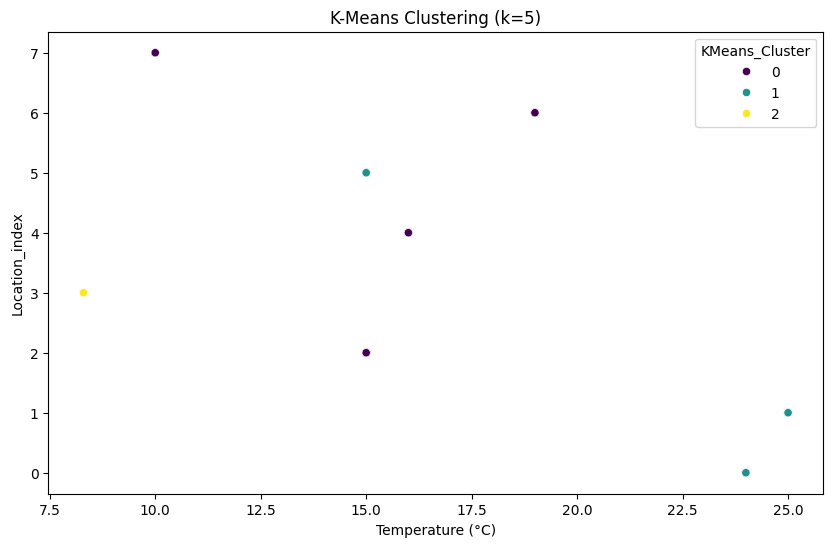

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (°C)', y='Location_index', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('K-Means Clustering (k=5)')
plt.show()

HIERARCHICAL CLUSTERING
#AGGLOMERATIVE CLUSTERING FUNCTION

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agglo=AgglomerativeClustering(n_clusters=3)
df['Agglo_Cluster']=agglo.fit_predict(X_scaled)


VISUALISE THE DATASET

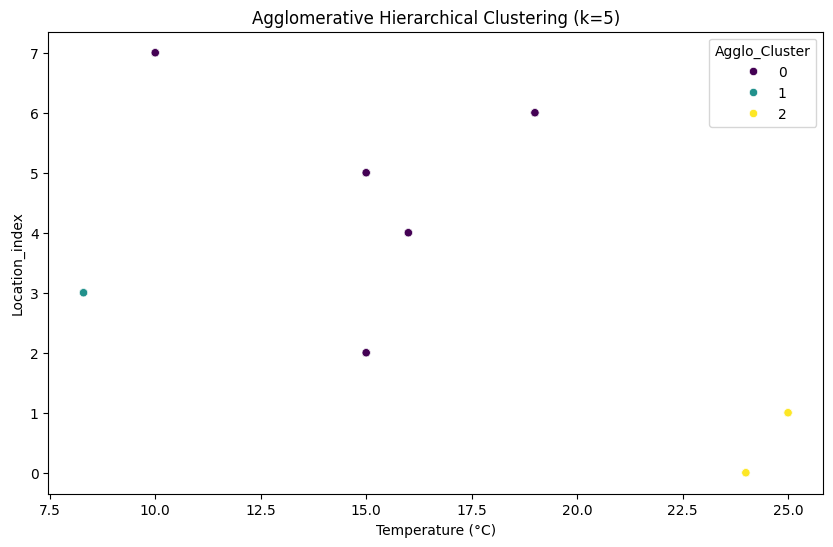

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (°C)', y='Location_index', hue='Agglo_Cluster', data=df, palette='viridis')
plt.title('Agglomerative Hierarchical Clustering (k=5)')
plt.show()

USE THE DENDROGRAM FOR HIERARCHICAL CLUSTERING

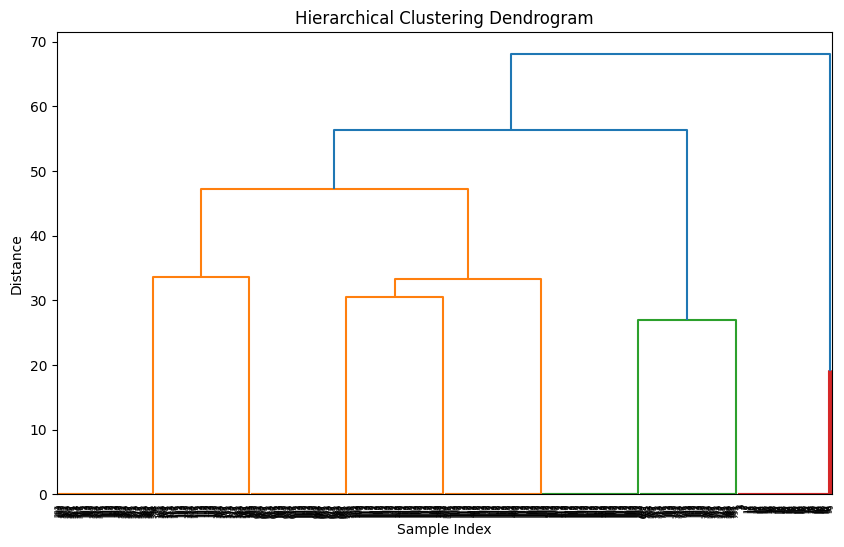

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled, 'ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

DBSCAN MODEL

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.5,min_samples=5)
df['DBSCAN_Cluster']=dbscan.fit_predict(X_scaled)


TO VIEW THE DATA

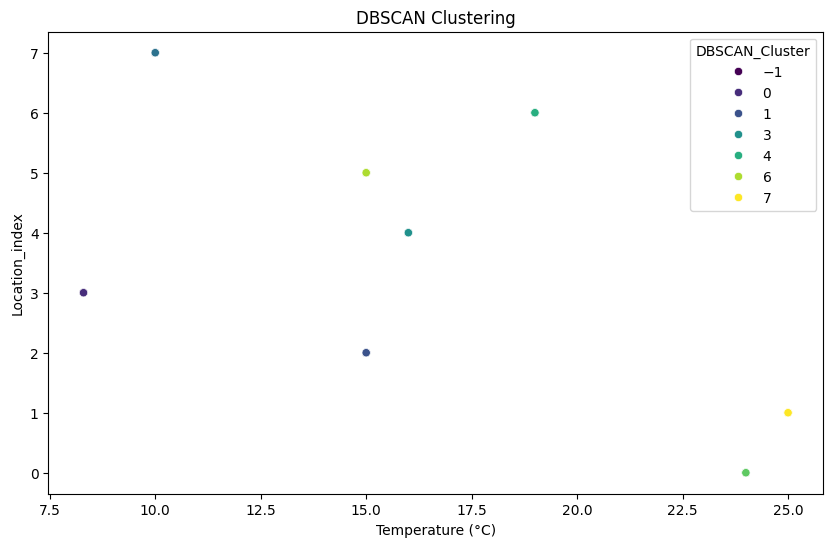

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (°C)', y='Location_index', hue='DBSCAN_Cluster', data=df, palette='viridis')
plt.title('DBSCAN Clustering')
plt.show()

#EVALUATION OF MODEL USING SILHOUETTE CLUSTERING

In [ ]:
from sklearn.metrics import silhouette_score
print("\nK-Means Silhouette Score:", silhouette_score(X_scaled, kmeans.labels_))
print("Agglomerative Hierarchical Silhouette Score:", silhouette_score(X_scaled, agglo.labels_))
print("DBSCAN Silhouette Score:", silhouette_score(X_scaled, dbscan.labels_))


K-Means Silhouette Score: 0.4269186417270657
Agglomerative Hierarchical Silhouette Score: 0.4786778691447906
DBSCAN Silhouette Score: 0.9987405541561712


CALINSKI INDEX

In [ ]:
from sklearn.metrics import calinski_harabasz_score
print("\nK-means Calinski_Harabasz Index:",calinski_harabasz_score(X, kmeans.labels_))
print("Agglomerative Hierarchical Calinski_Harabasz Index:",calinski_harabasz_score(X, agglo.labels_))
print("DBSCAN Calinski_Harabasz Index:",calinski_harabasz_score(X_scaled, dbscan.labels_))


K-means Calinski_Harabasz Index: 306.4721770610699
Agglomerative Hierarchical Calinski_Harabasz Index: 164.10954495554105
DBSCAN Calinski_Harabasz Index: 6.847691738396149e+31


ASSIGNMENT

# VISUALISE THE COMPARISON OF THE SCORES